# One-vs-Rest Hemisphere Classification: Error Analysis

## 1. Setup & Data Loading

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
import json
import sys

warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parents[0] if 'notebooks' in Path.cwd().parts else Path.cwd()
sys.path.insert(0, str(project_root))

# Visualization settings
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['savefig.dpi'] = 300

In [3]:
# Define paths

# Path to your results directory
RESULTS_BASE = Path('/home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis')  # CHANGE THIS
HEMISPHERE = 'left'  # or 'right'

# Path to your data directory (for region info)
DATA_DIR = Path('/home/sjoon/projects/brain_connectivity_classifier/data/')  # CHANGE THIS
# Derived paths
RESULTS_DIR = RESULTS_BASE / f'{HEMISPHERE}_hemisphere' / 'ovr'

print(f"Hemisphere: {HEMISPHERE.upper()}")
print(f"Results: {RESULTS_DIR}")

Hemisphere: LEFT
Results: /home/sjoon/projects/brain_connectivity_classifier/data/results/hemisphere_analysis/left_hemisphere/ovr


In [5]:
# Load numpy array results
print("Loading numpy arrays...\n")

predictions = np.load(RESULTS_DIR / 'cv_predictions.npy')
probabilities = np.load(RESULTS_DIR / 'cv_probabilities.npy')
true_labels = np.load(RESULTS_DIR / 'cv_true_labels.npy')
fold_indices = np.load(RESULTS_DIR / 'cv_fold_indices.npy')
confusion_matrix = np.load(RESULTS_DIR / 'confusion_matrix.npy')

print(f"✓ Predictions: {predictions.shape}")
print(f"✓ Probabilities: {probabilities.shape}")
print(f"✓ True labels: {true_labels.shape}")
print(f"✓ Fold indices: {fold_indices.shape}")
print(f"✓ Confusion matrix: {confusion_matrix.shape}")

# Load CSV metrics
per_region_metrics = pd.read_csv(RESULTS_DIR / 'per_region_metrics.csv')
network_metrics = pd.read_csv(RESULTS_DIR / 'network_metrics.csv')

print(f"\n✓ Per-region metrics: {per_region_metrics.shape}")
print(f"✓ Network metrics: {network_metrics.shape}")

# Load JSON metrics
with open(RESULTS_DIR / 'overall_metrics.json', 'r') as f:
    overall_metrics = json.load(f)

with open(RESULTS_DIR / 'fold_metrics.json', 'r') as f:
    fold_metrics = json.load(f)

print(f"\n✓ Overall metrics loaded")
print(f"✓ Fold metrics loaded ({len(fold_metrics)} folds)")

Loading numpy arrays...

✓ Predictions: (25984,)
✓ Probabilities: (25984, 116)
✓ True labels: (25984,)
✓ Fold indices: (25984,)
✓ Confusion matrix: (116, 116)

✓ Per-region metrics: (116, 9)
✓ Network metrics: (18, 7)

✓ Overall metrics loaded
✓ Fold metrics loaded (3 folds)


In [6]:
# Load region information from data directory
print("\nLoading region information...")

region_info = pd.read_csv(DATA_DIR /'LH_region_info.csv')
print(f"✓ Region info: {region_info.shape}")

region_info.head()


Loading region information...
✓ Region info: (116, 3)


,region_index,region_name,network
0,0,LH_VisPeri_ExStrSup_2,VisPeri
1,1,LH_DefaultC_Rsp_1,DefaultC
2,2,LH_VisCent_ExStr_4,VisCent
3,3,LH_VisCent_ExStr_1,VisCent
4,4,LH_SalVentAttnA_ParOper_1,SalVentAttnA


In [8]:
# Basic dataset information
n_samples = len(predictions)
n_regions = confusion_matrix.shape[0]
n_folds = len(np.unique(fold_indices))
n_subjects = len(fold_metrics) * fold_metrics[0]['n_test_subjects']  # Approximate

# Calculate overall accuracy
is_correct = (predictions == true_labels)
overall_accuracy = is_correct.mean()

print("="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"Total samples: {n_samples:,}")
print(f"Number of regions: {n_regions}")
print(f"Number of folds: {n_folds}")
print(f"Approximate subjects: {n_subjects}")
print(f"Overall accuracy: {overall_accuracy:.4f}")
print("="*80)

DATASET SUMMARY
Total samples: 25,984
Number of regions: 116
Number of folds: 3
Approximate subjects: 225
Overall accuracy: 0.9205


---
## 2. Create Analysis DataFrame

In [10]:
# Create comprehensive predictions dataframe
print("Creating analysis dataframe...\n")

# Map labels to region names
if 'region_name' in region_info.columns:
    region_names = region_info['region_name'].values
elif 'region' in region_info.columns:
    region_names = region_info['region'].values
else:
    region_names = [f"Region_{i}" for i in range(n_regions)]
    print("⚠️  Warning: Using generic region names")

# Create dataframe
df_analysis = pd.DataFrame({
    'fold': fold_indices,
    'true_label': true_labels,
    'predicted_label': predictions,
    'is_correct': is_correct,
    'true_region_name': [region_names[i] for i in true_labels],
    'predicted_region_name': [region_names[i] for i in predictions]
})

# Add probability metrics
df_analysis['confidence'] = probabilities.max(axis=1)
df_analysis['predicted_prob'] = probabilities[np.arange(len(probabilities)), predictions]
df_analysis['true_prob'] = probabilities[np.arange(len(probabilities)), true_labels]

# Add entropy
epsilon = 1e-10
prob_safe = probabilities + epsilon
df_analysis['entropy'] = -np.sum(prob_safe * np.log(prob_safe), axis=1)

# Add margin (top1 - top2 probability)
sorted_probs = np.sort(probabilities, axis=1)[:, ::-1]
df_analysis['margin'] = sorted_probs[:, 0] - sorted_probs[:, 1]

print("DataFrame created:")
print(f"\nShape: {df_analysis.shape}")
print(f"Columns: {df_analysis.columns.tolist()}")

Creating analysis dataframe...

DataFrame created:

Shape: (25984, 11)
Columns: ['fold', 'true_label', 'predicted_label', 'is_correct', 'true_region_name', 'predicted_region_name', 'confidence', 'predicted_prob', 'true_prob', 'entropy', 'margin']


In [11]:
df_analysis.head(20)

,fold,true_label,predicted_label,is_correct,true_region_name,predicted_region_name,confidence,predicted_prob,true_prob,entropy,margin
0,1,0,0,True,LH_VisPeri_ExStrSup_2,LH_VisPeri_ExStrSup_2,0.658987,0.658987,0.658987,1.658789,0.564893
1,1,1,1,True,LH_DefaultC_Rsp_1,LH_DefaultC_Rsp_1,0.793862,0.793862,0.793862,0.853152,0.652775
2,1,2,2,True,LH_VisCent_ExStr_4,LH_VisCent_ExStr_4,0.743118,0.743118,0.743118,1.281790,0.654486
3,1,3,3,True,LH_VisCent_ExStr_1,LH_VisCent_ExStr_1,0.681995,0.681995,0.681995,1.303972,0.562624
4,1,4,4,True,LH_SalVentAttnA_ParOper_1,LH_SalVentAttnA_ParOper_1,0.849114,0.849114,0.849114,0.833279,0.804530
5,1,5,5,True,LH_SomMotB_S2_2,LH_SomMotB_S2_2,0.710469,0.710469,0.710469,1.100882,0.562799
6,1,6,6,True,LH_DefaultA_pCunPCC_1,LH_DefaultA_pCunPCC_1,0.622852,0.622852,0.622852,1.285243,0.397799
7,1,7,7,True,LH_VisPeri_StriCal_1,LH_VisPeri_StriCal_1,0.903600,0.903600,0.903600,0.576425,0.866322
8,1,8,8,True,LH_DefaultB_PFCv_4,LH_DefaultB_PFCv_4,0.802796,0.802796,0.802796,1.012724,0.717172
9,1,9,9,True,LH_DorsAttnB_PostC_1,LH_DorsAttnB_PostC_1,0.862613,0.862613,0.862613,0.706633,0.812322


---
## 3. Data Validation

In [ ]:
# ========================================
# VALIDATION 1: Hemisphere Check
# ========================================

print("="*80)
print("VALIDATION: HEMISPHERE CHECK")
print("="*80)

if HEMISPHERE == 'left':
    valid_pattern = pd.Series(region_names).str.startswith('LH') | pd.Series(region_names).str.endswith('-lh')
elif HEMISPHERE == 'right':
    valid_pattern = pd.Series(region_names).str.startswith('RH') | pd.Series(region_names).str.endswith('-rh')
else:
    print(f"Unknown hemisphere: {HEMISPHERE}")
    valid_pattern = pd.Series([True] * len(region_names))

n_valid = valid_pattern.sum()
invalid_regions = pd.Series(region_names)[~valid_pattern]

print(f"Valid {HEMISPHERE} regions: {n_valid}/{n_regions}")

if len(invalid_regions) > 0:
    print(f"\n WARNING: Found {len(invalid_regions)} potentially invalid regions:")
    print(invalid_regions.tolist()[:10])
else:
    print(f"✓ All regions are valid {HEMISPHERE} hemisphere regions")

print("="*80)

VALIDATION: HEMISPHERE CHECK
Valid left regions: 116/116
✓ All regions are valid left hemisphere regions


In [18]:
# ========================================
# VALIDATION 2: Label & Probability Check
# ========================================

print("\nVALIDATION: Labels & Probabilities")
print("="*80)

# Check labels are continuous 0 to N-1
expected_labels = list(range(n_regions))
actual_labels = sorted(np.unique(true_labels))
labels_ok = (actual_labels == expected_labels)

if labels_ok:
    print(f"✓ Labels continuous: 0 to {n_regions-1}")
else:
    print(f"⚠️  Labels not continuous!")
    print(f"  Expected: 0 to {n_regions-1}")
    print(f"  Got: {actual_labels}")

# Check probabilities
prob_sums = probabilities.sum(axis=1)
prob_ok = np.allclose(prob_sums, 1.0, atol=1e-5)

if prob_ok:
    print(f"✓ Probabilities: {probabilities.shape[1]} columns, all sum to 1.0")
else:
    print(f"⚠️  WARNING: Some probabilities don't sum to 1.0")
    print(f"  Sum range: [{prob_sums.min():.6f}, {prob_sums.max():.6f}]")

# Check for NaN/Inf
has_nan = np.any(np.isnan(probabilities))
has_inf = np.any(np.isinf(probabilities))

if not has_nan and not has_inf:
    print(f"✓ No NaN or Inf values in probabilities")
else:
    if has_nan:
        print(f"✗ ERROR: NaN values detected in probabilities!")
    if has_inf:
        print(f"✗ ERROR: Inf values detected in probabilities!")

print(f"✓ Data validation completed")
print("="*80)


VALIDATION: Labels & Probabilities
✓ Labels continuous: 0 to 115
✓ Probabilities: 116 columns, all sum to 1.0
✓ No NaN or Inf values in probabilities
✓ Data validation completed


---
## 4. Helper Functions & Network Mapping

In [19]:
def extract_network_from_region(region_name):
    """Extract network name from region name."""
    # Remove hemisphere prefix/suffix
    name = region_name
    if name.startswith('LH_') or name.startswith('RH_'):
        name = name[3:]
    if name.endswith('-lh') or name.endswith('-rh'):
        name = name[:-3]
    
    # Extract network (everything before last underscore+number)
    parts = name.split('_')
    if parts[-1].isdigit():
        network = '_'.join(parts[:-1])
    else:
        network = name
    return network

# def save_figure(fig, filename):
#     """Save figure to figures directory."""
#     filepath = FIGURES_DIR / filename
#     fig.savefig(filepath, dpi=300, bbox_inches='tight')
#     print(f"  ✓ Saved: {filename}")

print("✓ Helper functions defined")

✓ Helper functions defined


In [20]:
# Create network mapping
print("Creating network mapping...\n")

# Try to get network from region_info first
if 'network' in region_info.columns:
    region_to_network = dict(zip(region_info['region_name'], region_info['network']))
    print("✓ Using network from region_info")
else:
    # Extract from region names
    region_to_network = {region: extract_network_from_region(region) for region in region_names}
    print("✓ Extracted network from region names")

# Add network columns to analysis dataframe
df_analysis['true_network'] = df_analysis['true_region_name'].map(region_to_network)
df_analysis['predicted_network'] = df_analysis['predicted_region_name'].map(region_to_network)

unique_networks = sorted(set(region_to_network.values()))
n_networks = len(unique_networks)

print(f"Networks: {n_networks}")
print(f"Networks list: {unique_networks}")

# Count regions per network
network_counts = pd.Series(region_to_network.values()).value_counts().sort_index()
print(f"\nRegions per network:")
for network, count in network_counts.items():
    print(f"  {network:15s}: {count:3d} regions")

print(f"\n✓ Network mapping complete")

Creating network mapping...

✓ Using network from region_info
Networks: 18
Networks list: ['ContA', 'ContB', 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'DorsAttnA', 'DorsAttnB', 'LimbicA', 'LimbicB', 'SalVentAttnA', 'SalVentAttnB', 'SomMotA', 'SomMotB', 'Subcortical', 'TempPar', 'VisCent', 'VisPeri']

Regions per network:
  ContA          :  10 regions
  ContB          :   5 regions
  ContC          :   3 regions
  DefaultA       :   8 regions
  DefaultB       :  13 regions
  DefaultC       :   3 regions
  DorsAttnA      :   6 regions
  DorsAttnB      :   5 regions
  LimbicA        :   4 regions
  LimbicB        :   2 regions
  SalVentAttnA   :   7 regions
  SalVentAttnB   :   4 regions
  SomMotA        :   8 regions
  SomMotB        :   8 regions
  Subcortical    :  16 regions
  TempPar        :   2 regions
  VisCent        :   6 regions
  VisPeri        :   6 regions

✓ Network mapping complete


---
## 5. Overall Performance Summary

In [21]:
# Calculate top-k accuracy
def calculate_topk_accuracy(k):
    topk_preds = np.argsort(-probabilities, axis=1)[:, :k]
    correct = np.any(topk_preds == true_labels[:, np.newaxis], axis=1)
    return correct.mean()

k_values = [1, 3, 5, 10, 20]
topk_accuracies = [calculate_topk_accuracy(k) for k in k_values]

print("="*80)
print("OVERALL PERFORMANCE")
print("="*80)
print(f"Total samples: {n_samples:,}")
print(f"Overall accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Mean confidence: {df_analysis['confidence'].mean():.4f}")
print(f"Mean entropy: {df_analysis['entropy'].mean():.4f}")
print(f"\nTop-K Accuracy:")
for k, acc in zip(k_values, topk_accuracies):
    print(f"  Top-{k:2d}: {acc:.4f} ({acc*100:.2f}%)")
print("="*80)

OVERALL PERFORMANCE
Total samples: 25,984
Overall accuracy: 0.9205 (92.05%)
Mean confidence: 0.6952
Mean entropy: 1.2188

Top-K Accuracy:
  Top- 1: 0.9205 (92.05%)
  Top- 3: 0.9704 (97.04%)
  Top- 5: 0.9824 (98.24%)
  Top-10: 0.9919 (99.19%)
  Top-20: 0.9972 (99.72%)


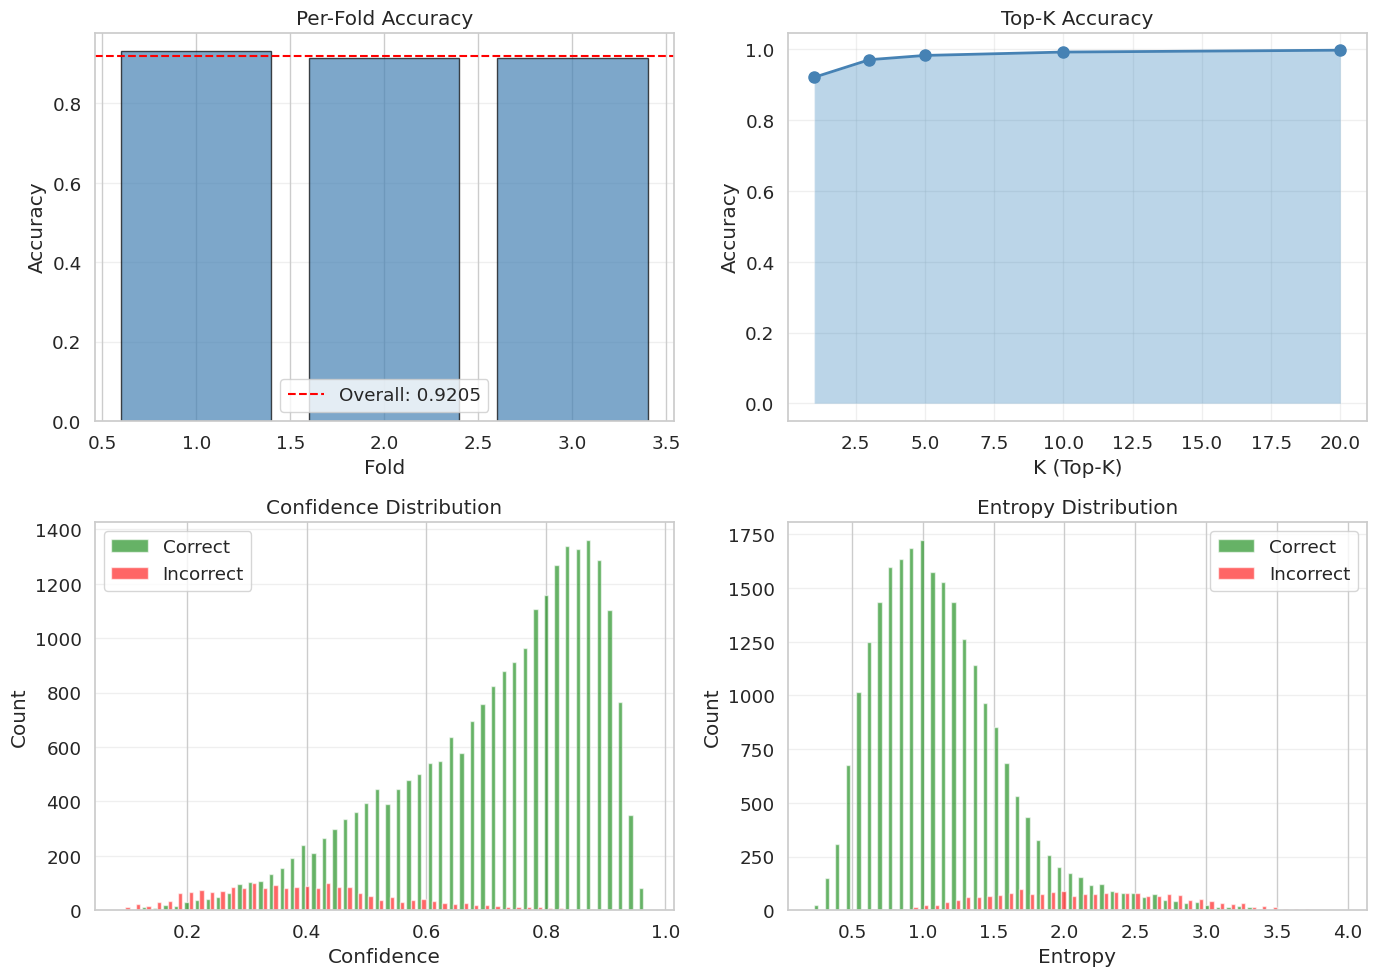

In [22]:
# Visualize performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-fold accuracy
fold_acc = df_analysis.groupby('fold')['is_correct'].mean()
axes[0, 0].bar(fold_acc.index, fold_acc.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axhline(overall_accuracy, color='r', linestyle='--', label=f'Overall: {overall_accuracy:.4f}')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Per-Fold Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Top-k accuracy
axes[0, 1].plot(k_values, topk_accuracies, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 1].fill_between(k_values, topk_accuracies, alpha=0.3)
axes[0, 1].set_xlabel('K (Top-K)')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Top-K Accuracy')
axes[0, 1].grid(True, alpha=0.3)

# Confidence distribution
correct_conf = df_analysis[df_analysis['is_correct']]['confidence']
incorrect_conf = df_analysis[~df_analysis['is_correct']]['confidence']
axes[1, 0].hist([correct_conf, incorrect_conf], bins=50, alpha=0.6,
                label=['Correct', 'Incorrect'], color=['green', 'red'])
axes[1, 0].set_xlabel('Confidence')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Confidence Distribution')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Entropy distribution
correct_ent = df_analysis[df_analysis['is_correct']]['entropy']
incorrect_ent = df_analysis[~df_analysis['is_correct']]['entropy']
axes[1, 1].hist([correct_ent, incorrect_ent], bins=50, alpha=0.6,
                label=['Correct', 'Incorrect'], color=['green', 'red'])
axes[1, 1].set_xlabel('Entropy')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Entropy Distribution')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
# save_figure(fig, 'overall_performance.png')
plt.show()

---
## 6. Within-Network vs Cross-Network Errors ⭐

In [23]:
# Analyze within vs cross-network errors
errors = df_analysis[~df_analysis['is_correct']].copy()
n_errors = len(errors)

within_network = errors['true_network'] == errors['predicted_network']
n_within = within_network.sum()
n_cross = n_errors - n_within

pct_within = (n_within / n_errors) * 100
pct_cross = (n_cross / n_errors) * 100

print("="*80)
print("WITHIN-NETWORK vs CROSS-NETWORK ERRORS")
print("="*80)
print(f"Total errors: {n_errors:,}\n")
print(f"Within-network errors: {n_within:,} ({pct_within:.2f}%)")
print(f"Cross-network errors:  {n_cross:,} ({pct_cross:.2f}%)")

# Expected error rate (random chance)
network_sizes = network_counts.values
total_regions_check = network_sizes.sum()
expected_within_rate = sum((size / total_regions_check) ** 2 for size in network_sizes)
expected_within = n_errors * expected_within_rate
expected_cross = n_errors * (1 - expected_within_rate)

print(f"\nExpected (random chance):")
print(f"  Within-network: {expected_within:.1f} ({expected_within_rate*100:.2f}%)")
print(f"  Cross-network:  {expected_cross:.1f} ({(1-expected_within_rate)*100:.2f}%)")

# Chi-square test
observed = np.array([n_within, n_cross])
expected = np.array([expected_within, expected_cross])
chi2, p_val = stats.chisquare(observed, expected)

print(f"\nChi-square test: χ² = {chi2:.4f}, p = {p_val:.4e}")

if p_val < 0.05:
    if n_within > expected_within:
        print(f"\n✓ Within-network errors are SIGNIFICANTLY MORE common (p < 0.05)")
        print(f"  → Regions within same network are more confusable")
    else:
        print(f"\n✓ Within-network errors are SIGNIFICANTLY LESS common (p < 0.05)")
else:
    print(f"\n→ Error distribution matches random chance (p >= 0.05)")

print("="*80)

WITHIN-NETWORK vs CROSS-NETWORK ERRORS
Total errors: 2,065

Within-network errors: 149 (7.22%)
Cross-network errors:  1,916 (92.78%)

Expected (random chance):
  Within-network: 150.7 (7.30%)
  Cross-network:  1914.3 (92.70%)

Chi-square test: χ² = 0.0207, p = 8.8558e-01

→ Error distribution matches random chance (p >= 0.05)


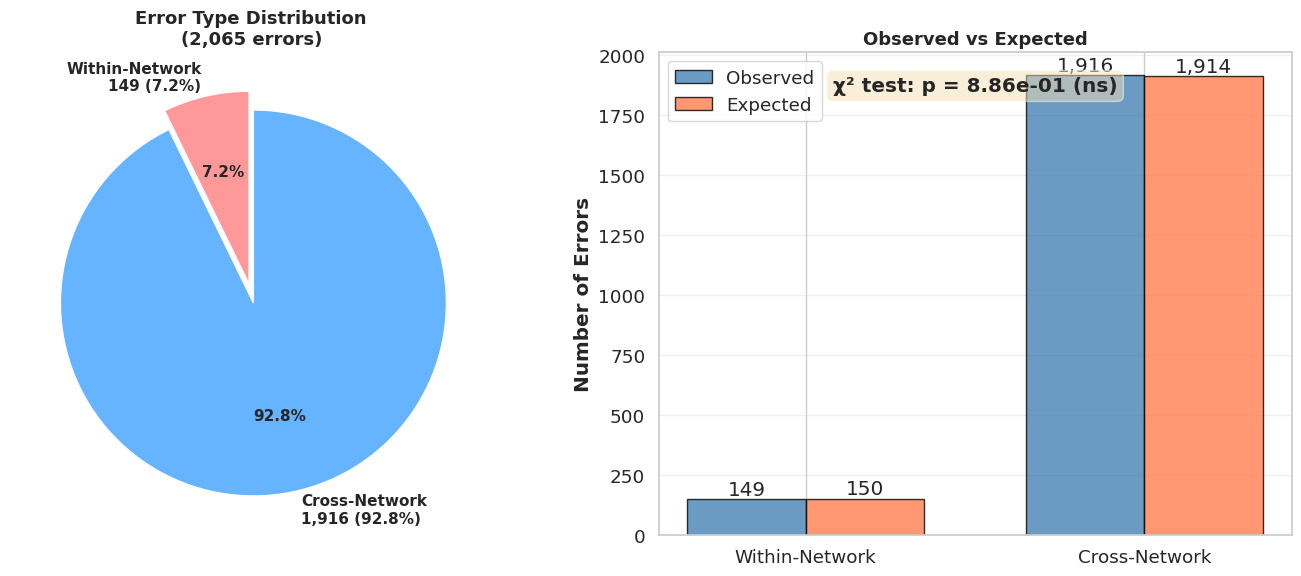

In [24]:
# Visualize within vs cross-network errors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0.05)
labels = [f'Within-Network\n{n_within:,} ({pct_within:.1f}%)',
          f'Cross-Network\n{n_cross:,} ({pct_cross:.1f}%)']

axes[0].pie([n_within, n_cross], labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title(f'Error Type Distribution\n({n_errors:,} errors)', fontsize=13, fontweight='bold')

# Bar chart: observed vs expected
x = np.arange(2)
width = 0.35
bars1 = axes[1].bar(x - width/2, [n_within, n_cross], width,
                    label='Observed', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = axes[1].bar(x + width/2, [expected_within, expected_cross], width,
                    label='Expected', color='coral', alpha=0.8, edgecolor='black')

axes[1].set_ylabel('Number of Errors', fontweight='bold')
axes[1].set_title('Observed vs Expected', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Within-Network', 'Cross-Network'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add values
for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')

sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
axes[1].text(0.5, 0.95, f'χ² test: p = {p_val:.2e} ({sig})',
            transform=axes[1].transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontweight='bold')

plt.tight_layout()
# save_figure(fig, 'within_vs_cross_network_errors.png')
plt.show()

---
## 7. Network-Level Analysis

In [25]:
# Network confusion matrix
print("Creating network confusion matrix...\n")

network_confusion = pd.DataFrame(0, index=sorted(unique_networks), columns=sorted(unique_networks))

for true_region, pred_region in zip(df_analysis['true_region_name'], df_analysis['predicted_region_name']):
    true_net = region_to_network[true_region]
    pred_net = region_to_network[pred_region]
    network_confusion.loc[true_net, pred_net] += 1

# Normalize
network_confusion_norm = network_confusion.div(network_confusion.sum(axis=1), axis=0)

print("Network Confusion Matrix:")
print(network_confusion)

# Per-network performance
network_perf = df_analysis.groupby('true_network').agg({
    'is_correct': ['sum', 'count', 'mean'],
    'confidence': 'mean',
    'entropy': 'mean'
}).round(4)

network_perf.columns = ['n_correct', 'n_samples', 'accuracy', 'avg_confidence', 'avg_entropy']
network_perf = network_perf.reset_index()
network_perf = network_perf.sort_values('accuracy', ascending=False)

print(f"\nPer-Network Performance:")
print(network_perf.to_string(index=False))

# Save
# network_confusion.to_csv(TABLES_DIR / 'network_confusion_matrix.csv')
# network_confusion_norm.to_csv(TABLES_DIR / 'network_confusion_normalized.csv')
# network_perf.to_csv(TABLES_DIR / 'network_performance_analysis.csv', index=False)
print("\n✓ Network analysis saved")

Creating network confusion matrix...

Network Confusion Matrix:
              ContA  ContB  ContC  DefaultA  DefaultB  DefaultC  DorsAttnA  \
ContA          2030     15      7         5        22         6         11   
ContB            12   1007      0         4        19         4          7   
ContC             6      0    632         4         4         1          4   
DefaultA         11      4      3      1703        16         0          3   
DefaultB         22     29      2         9      2649         9         11   
DefaultC          1      6      0         0         7       622          1   
DorsAttnA         2      5      3         7        14         2       1259   
DorsAttnB         5      5      2         2         5         1          4   
LimbicA          23     10      1         1        16         5          8   
LimbicB           4      8      1         2         9         1          4   
SalVentAttnA      3     10      1         5        20         7          4   


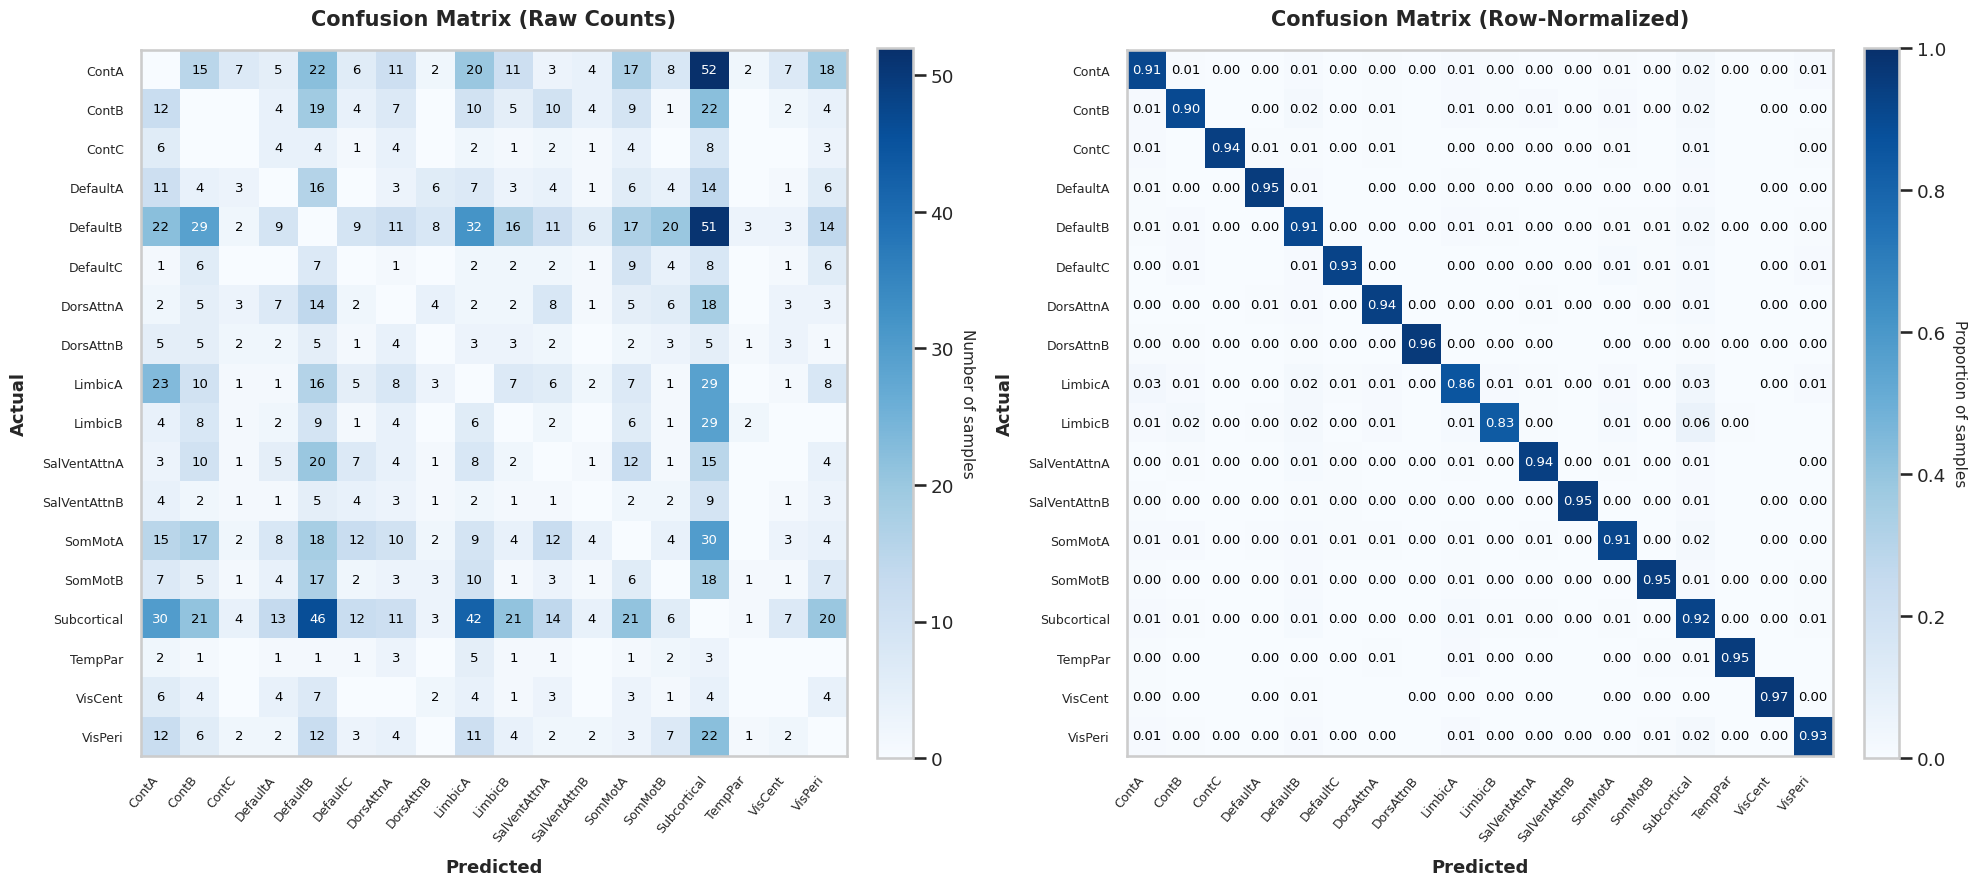

In [80]:
# Visualize network confusion matrices

def plot_confusion_counts_and_norm(cm, labels,
                                   title_counts="Confusion Matrix (Raw Counts)",
                                   title_norm="Confusion Matrix (Row-Normalized)"):

    cm = np.array(cm)

    # --- normalized version (per row) ---
    with np.errstate(all='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)  # replace NaNs from zero-rows

    # --- create side-by-side subplots ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

    # ===== LEFT: raw counts (your logic, minimally adapted) =====
    cm_counts = cm.copy()
    np.fill_diagonal(cm_counts, 0)

    im1 = ax1.imshow(cm_counts, cmap='Blues', interpolation='nearest')
    cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('Number of samples', rotation=270, labelpad=15, fontsize=11)

    thresh1 = cm_counts.max() / 2. if cm_counts.max() > 0 else 1
    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            val = cm_counts[i, j]
            if val > 0:
                color = 'white' if val > thresh1 else 'black'
                ax1.text(j, i, f"{int(val)}", ha='center', va='center',
                         color=color, fontsize=9.5, fontweight='medium')

    ax1.set_xticks(range(len(labels)))
    ax1.set_yticks(range(len(labels)))
    ax1.set_xticklabels(labels, rotation=50, ha='right', fontsize=9)
    ax1.set_yticklabels(labels, fontsize=9)
    ax1.set_xlabel("Predicted", fontsize=13, fontweight='bold', labelpad=10)
    ax1.set_ylabel("Actual",   fontsize=13, fontweight='bold', labelpad=10)
    ax1.set_title(title_counts, fontsize=15, fontweight='bold', pad=18)
    ax1.grid(False)

    # ===== RIGHT: normalized (0–1) =====
    im2 = ax2.imshow(cm_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('Proportion of samples', rotation=270, labelpad=15, fontsize=11)

    thresh2 = cm_norm.max() / 2. if cm_norm.max() > 0 else 0.5
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            val = cm_norm[i, j]
            if val > 0:
                color = 'white' if val > thresh2 else 'black'
                ax2.text(j, i, f"{val:.2f}", ha='center', va='center',
                         color=color, fontsize=9.5, fontweight='medium')

    ax2.set_xticks(range(len(labels)))
    ax2.set_yticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=50, ha='right', fontsize=9)
    ax2.set_yticklabels(labels, fontsize=9)
    ax2.set_xlabel("Predicted", fontsize=13, fontweight='bold', labelpad=10)
    ax2.set_ylabel("Actual",   fontsize=13, fontweight='bold', labelpad=10)
    ax2.set_title(title_norm, fontsize=15, fontweight='bold', pad=18)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

labels = network_confusion.index.tolist()
cm = network_confusion.values

plot_confusion_counts_and_norm(cm, labels)


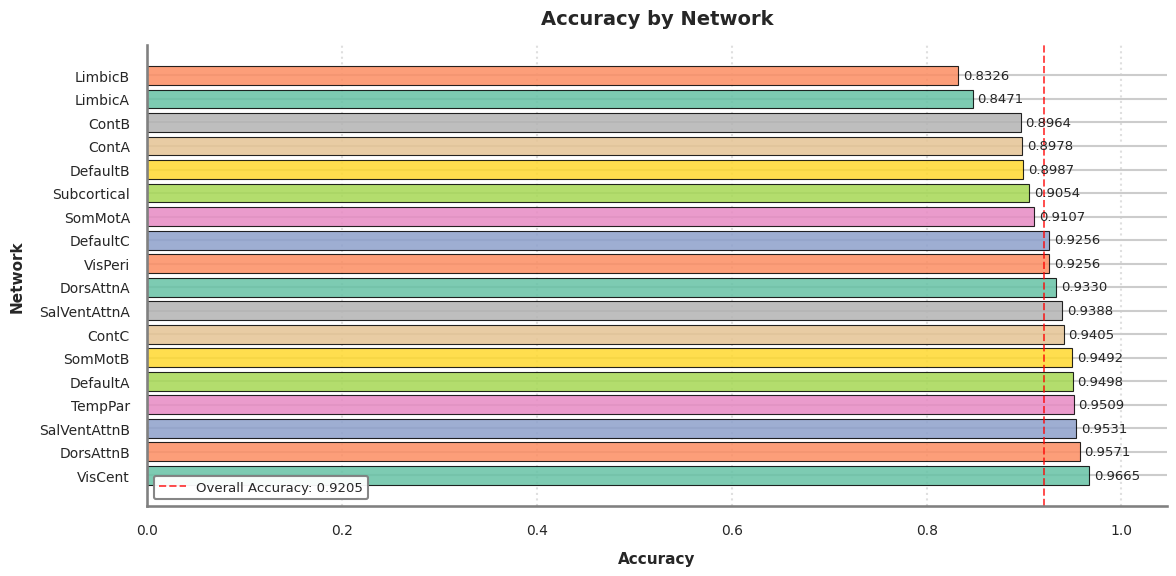

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Accuracy by Network'}, xlabel='Accuracy', ylabel='Network'>)

In [95]:
# Visualize network performance
def plot_network_accuracy(network_perf, overall_accuracy, figsize=(12, 6)):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color palette - professional and colorblind-friendly
    colors = sns.color_palette("Set2", n_colors=len(network_perf))
    
    # Horizontal bars
    bars = ax.barh(
        y=network_perf['true_network'],
        width=network_perf['accuracy'],
        color=colors,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    # Overall accuracy reference line
    ax.axvline(
        x=overall_accuracy,
        color='red',
        linestyle='--',
        linewidth=1.4,
        alpha=0.7,
        label=f'Overall Accuracy: {overall_accuracy:.4f}'
    )
    
    # Add value labels on the bars
    for bar, value in zip(bars, network_perf['accuracy']):
        ax.text(
            x=value + 0.005,                    # small offset from bar end
            y=bar.get_y() + bar.get_height()/2,
            s=f'{value:.4f}',
            va='center',
            ha='left',
            fontsize=9.5,
            fontweight='medium'
        )
    
    # Styling
    ax.set_xlabel('Accuracy', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel('Network', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_title('Accuracy by Network', 
                 fontsize=14, 
                 fontweight='bold', 
                 pad=15)
    
    # Grid & spines
    ax.grid(axis='x', alpha=0.25, linestyle=':', color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    
    # Legend
    ax.legend(
        loc='lower left',
        fontsize=9.5,
        frameon=True,
        edgecolor='gray',
        facecolor='white',
        framealpha=0.95
    )
    
    # Ensure enough space for labels
    ax.set_xlim(0, max(1.0, network_perf['accuracy'].max() + 0.08))
    
    # Clean tick labels
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

plot_network_accuracy(network_perf, overall_accuracy)

---
## 8. Region-Level Analysis

In [104]:
# Per-region accuracy
region_accuracy = df_analysis.groupby('true_region_name').agg({
    'is_correct': ['sum', 'count', 'mean'],
    'confidence': 'mean',
    'entropy': 'mean'
}).round(4)

region_accuracy.columns = ['n_correct', 'n_total', 'accuracy', 'avg_confidence', 'avg_entropy']
region_accuracy = region_accuracy.reset_index()
region_accuracy['network'] = region_accuracy['true_region_name'].map(region_to_network)
region_accuracy_sorted = region_accuracy.sort_values('accuracy', ascending=False)

print("Top 10 BEST regions:")
print(region_accuracy_sorted.head(10)[['true_region_name', 'network', 'accuracy']].to_string(index=False))

print("\nTop 10 WORST regions:")
print(region_accuracy_sorted.tail(10)[['true_region_name', 'network', 'accuracy']].to_string(index=False))

# Most confused pairs
confused_pairs = []
for i in range(n_regions):
    for j in range(n_regions):
        if i != j:
            count = confusion_matrix[i, j]
            if count > 0:
                true_region = region_names[i]
                pred_region = region_names[j]
                true_net = region_to_network[true_region]
                pred_net = region_to_network[pred_region]
                confused_pairs.append({
                    'true_region': true_region,
                    'predicted_region': pred_region,
                    'true_network': true_net,
                    'predicted_network': pred_net,
                    'count': int(count),
                    'within_network': true_net == pred_net
                })

confused_pairs_df = pd.DataFrame(confused_pairs).sort_values('count', ascending=False)

print("\nTop 20 Most Confused Region Pairs:")
print(confused_pairs_df.head(20).to_string(index=False))

Top 10 BEST regions:
         true_region_name      network  accuracy
       LH_DefaultB_Temp_2     DefaultB    0.9955
       LH_VisCent_ExStr_5      VisCent    0.9955
       LH_DefaultA_PFCm_3     DefaultA    0.9911
     LH_DorsAttnB_PostC_1    DorsAttnB    0.9911
 LH_SalVentAttnA_FrOper_2 SalVentAttnA    0.9911
         LH_SomMotB_Aud_1      SomMotB    0.9911
LH_SalVentAttnA_ParOper_1 SalVentAttnA    0.9911
             NAc-shell-lh  Subcortical    0.9911
        LH_DefaultC_Rsp_1     DefaultC    0.9911
       LH_DefaultA_PFCd_1     DefaultA    0.9866

Top 10 WORST regions:
     true_region_name      network  accuracy
LH_VisPeri_ExStrInf_3      VisPeri    0.7991
LH_SalVentAttnA_Ins_1 SalVentAttnA    0.7991
   LH_DefaultB_PFCd_3     DefaultB    0.7812
LH_LimbicA_TempPole_3      LimbicA    0.7768
   LH_DefaultB_PFCv_2     DefaultB    0.7232
   LH_DefaultB_PFCv_1     DefaultB    0.6964
     LH_LimbicB_OFC_1      LimbicB    0.6830
         LH_SomMotA_8      SomMotA    0.6741
            

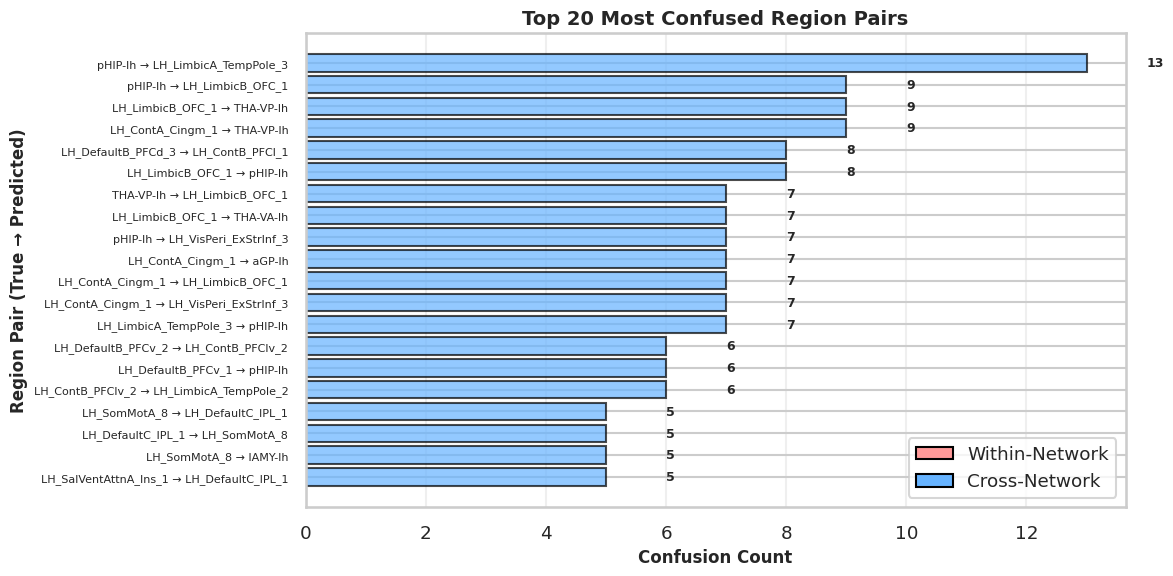

In [103]:
# Visualize top confused pairs
fig, ax = plt.subplots(figsize=(12, 6))

top20 = confused_pairs_df.head(20).sort_values('count')
colors = ['#ff9999' if within else '#66b3ff' for within in top20['within_network']]
labels = [f"{row['true_region']} → {row['predicted_region']}" for _, row in top20.iterrows()]

y_pos = np.arange(len(top20))
bars = ax.barh(y_pos, top20['count'], color=colors, edgecolor='black', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Confusion Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Region Pair (True → Predicted)', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Confused Region Pairs', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top20['count']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff9999', edgecolor='black', label='Within-Network'),
    Patch(facecolor='#66b3ff', edgecolor='black', label='Cross-Network')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

---
## 9. Summary Report

In [35]:
# Generate summary report
summary = f"""
{'='*80}
ERROR ANALYSIS SUMMARY - {HEMISPHERE.upper()} HEMISPHERE
{'='*80}

DATASET:
--------
Total samples: {n_samples:,}
Subjects: ~{n_subjects}
Regions: {n_regions}
Networks: {n_networks}
Folds: {n_folds}

OVERALL PERFORMANCE:
-------------------
Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)
Top-5 Accuracy: {topk_accuracies[2]:.4f} ({topk_accuracies[2]*100:.2f}%)
Mean Confidence: {df_analysis['confidence'].mean():.4f}
Mean Entropy: {df_analysis['entropy'].mean():.4f}

ERROR BREAKDOWN:
---------------
Total Errors: {n_errors:,}
Within-Network: {n_within:,} ({pct_within:.1f}%)
Cross-Network: {n_cross:,} ({pct_cross:.1f}%)
Statistical Test: χ² = {chi2:.4f}, p = {p_val:.4e}

NETWORK PERFORMANCE:
-------------------
Best: {network_perf.iloc[0]['true_network']} ({network_perf.iloc[0]['accuracy']:.4f})
Worst: {network_perf.iloc[-1]['true_network']} ({network_perf.iloc[-1]['accuracy']:.4f})

REGION PERFORMANCE:
------------------
Best: {region_accuracy_sorted.iloc[0]['true_region_name']} ({region_accuracy_sorted.iloc[0]['accuracy']:.4f})
Worst: {region_accuracy_sorted.iloc[-1]['true_region_name']} ({region_accuracy_sorted.iloc[-1]['accuracy']:.4f})

MOST CONFUSED PAIR:
------------------
{confused_pairs_df.iloc[0]['true_region']} → {confused_pairs_df.iloc[0]['predicted_region']}
Count: {confused_pairs_df.iloc[0]['count']}
Type: {'Within-Network' if confused_pairs_df.iloc[0]['within_network'] else 'Cross-Network'}
{'='*80}
"""
print(summary)

# Save summary
# with open(OUTPUT_DIR / 'analysis_summary.txt', 'w') as f:
#     f.write(summary)

# print(f"\n✓ Summary saved to: {OUTPUT_DIR / 'analysis_summary.txt'}")


ERROR ANALYSIS SUMMARY - LEFT HEMISPHERE

DATASET:
--------
Total samples: 25,984
Subjects: ~225
Regions: 116
Networks: 18
Folds: 3

OVERALL PERFORMANCE:
-------------------
Accuracy: 0.9205 (92.05%)
Top-5 Accuracy: 0.9824 (98.24%)
Mean Confidence: 0.6952
Mean Entropy: 1.2188

ERROR BREAKDOWN:
---------------
Total Errors: 2,065
Within-Network: 149 (7.2%)
Cross-Network: 1,916 (92.8%)
Statistical Test: χ² = 0.0207, p = 8.8558e-01

NETWORK PERFORMANCE:
-------------------
Best: VisCent (0.9665)
Worst: LimbicB (0.8326)

REGION PERFORMANCE:
------------------
Best: LH_DefaultB_Temp_2 (0.9955)
Worst: LH_ContA_Cingm_1 (0.4955)

MOST CONFUSED PAIR:
------------------
pHIP-lh → LH_LimbicA_TempPole_3
Count: 13
Type: Cross-Network

